# 와인 데이터 분석해보기
현재 프로젝트는 이론적으로 공부하던
사분위수, 통계수치들, 행렬곱, 가중치, bias, 데이터셋, 신경망, loss, Momentum, Noise, 활성화 함수 등을 직접 사용해보며 강화 학습을 위해 만든 파일입니디.

In [ ]:
import pandas as pd

# pandas의 .read_csv(경로, 나누는 기준(csv이므로 ';'))을 통해 데이터를 DataFrame로 바꿔준다.
df = pd.read_csv("../../resource/wine_quality/winequality-red.csv", sep=";")


# 결과로 총 12개의 컬럼이 나오며 
# print(df.head())
# null값은 없고, quality만 int64이며 나머지는 float64이다.
# 순서대로 
# fixed acidity         고정산도
# volatile acidity      휘발성 산도
# citric acid           구연산
# residual sugar        잔당
# chlorides             염화물
# free sulfur dioxide   자유 이산화황
# total sulfur dioxide  총 이산화황
# density               밀도
# pH                    산성도
# sulphates             황산염
# alcohol               알코올 도수
# quality               품질 점수
# 와 같은 모습으로 나온다. 전체적으로 화학용어들이 나와있다. 
# print(df.info())

# print(df["quality"].value_counts().sort_index())
# 품질 점수의 경우에는 3~8점으로 나뉘어져 있으며 5.6점에서 0.8의 표준편차가 존재한다.
# 특이한점은 "자유 이산화황"이 이상치가 있는지 평균 15에 10의 표준편차를 가지고 있다. 첨도를 통해 분산도를 확인 가능할 것 같다.
# 황산염도 좀 표준편차 비율이 약 18%정도 되는걸로 보이는데 큰 문제는 아닌것 같다.
# 염화 물은 표준편차가 평균의 50%가 약간 넘는다.
# 총 이산화황이 표준평차가 평균의 약 80% 정도 되는걸로 보인다. ㅁ낳이 크다.
df.describe()


quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


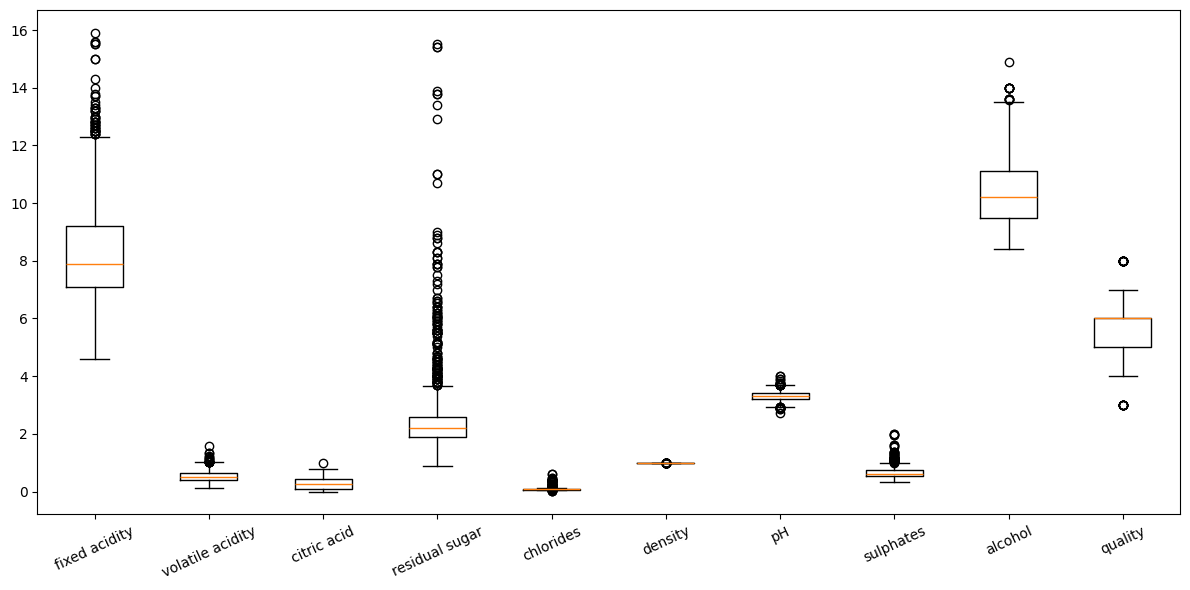

In [49]:
# 이번에는 이전에 잡은 값들을 통해 박스플롯을 나타내보며 이상치를 확인해보겠습니다.
import matplotlib.pyplot as plt

mask = df.columns[(df.columns != "total sulfur dioxide") & (df.columns != "free sulfur dioxide")]
plt.figure(figsize=(12, 6))
plt.boxplot(df[mask].values)
plt.xticks(
  range(1, len(mask) + 1),
  list(df[mask].columns),
  rotation=25,
  ha="center")
plt.tight_layout()
plt.show()

### 제 생각 ###
# 이상치가 있는 것의 순서로는
# 1. total sulfur dioxide (총 이산화 양)
# 2. free sulfur dioxide (자유 이산화 양)
# 3. resigual sugar (잔당)
# 4. fixed acidity (고정 산도)
# 이며
# 제일 문제가 없는 값은 결과, 밀도, 염화물 이였습니다.

### 문제 ###
# 현재 이상치를 판단한 방식은 박스플롯을 찍었을 때 가장 숫자 범위가 넓고, 많이 퍼져있어 ""보이는"" 데이터들을 순서대로 지우면서 나타낸 방식입니다.
# 하지만 이는 데이터 자체가 비율적으로 차이가 있을 수 있기 때문에 이전에 말했던 **정규화** 또는 **표준화** 또는 사분위수를 통한 비율을 직접 계산하는 방식을 선택할 수 있습니다.


In [ ]:
# 사분위수를 통한 진짜 이상치(IQR 기준) 문제 컬럼들 알아보기.
import numpy as np

summary = []

for col in df.columns:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  upper_bounder = q3 + 1.5 * iqr
  lower_bounder = q1 - 1.5 * iqr

  outlier_count = ((df[col] < lower_bounder) | (upper_bounder < df[col])).sum()
  outlier_ratio = outlier_count/len(df) *100


  summary.append({
    "column": col,
    "q1": q1,
    "q3": q3,
    "IQR": iqr,
    "upper_bounder": upper_bounder,
    "lower_bounder": lower_bounder,
    "outlier_count": outlier_count,
    "outlier_ratio": outlier_ratio
  })

outlier_df = pd.DataFrame(summary)
# print(outlier_df)
print(outlier_df[["column", "outlier_count"]].sort_values("outlier_count", ascending=False))
print(f" --- 비율 순서 --- ")
print(outlier_df[["column", "outlier_ratio"]].sort_values("outlier_ratio", ascending=False))

# 비율은
# 1등이 잔설탕 (residual sugar0)
# 2등이 염화 이온(물) 나머지는 다 0~3 정도이다. (chlorides)

# 개수는 
# 1등이 잔설탕 (residual sugar)
# 2등이 염화물로 동일했다. (chlorides)
# 나머지는 60 이하로 골고루 있었다.

                  column  outliner_count
3         residual sugar             155
4              chlorides             112
9              sulphates              59
6   total sulfur dioxide              55
0          fixed acidity              49
7                density              45
8                     pH              35
5    free sulfur dioxide              30
11               quality              28
1       volatile acidity              19
10               alcohol              13
2            citric acid               1
 --- 비율 순서 --- 
                  column  outliner_ratio
3         residual sugar        9.693558
4              chlorides        7.004378
9              sulphates        3.689806
6   total sulfur dioxide        3.439650
0          fixed acidity        3.064415
7                density        2.814259
8                     pH        2.188868
5    free sulfur dioxide        1.876173
11               quality        1.751094
1       volatile acidity        1.188243


In [58]:
df = pd.read_csv("../../resource/wine_quality/winequality-red.csv", sep=";")

col = "residual sugar" # 잔당

q1 = df[col].quantile(0.25)
q3 = df[col].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

residual_sugar_outlier_mask = (df[col] < lower) | (upper < df[col])
print(f"데이터: {len(df)}개")
print(f"이상치: {len(df[residual_sugar_outlier_mask])}개")
print(f"정상치: {len(df[~residual_sugar_outlier_mask])}개")

데이터: 1599개
이상치: 155개
정상치: 1444개


In [92]:
# 이상치 그룹과 일반 그룹의 quality 평균 비교
print(f"이상치 quality 평균: {df[residual_sugar_outlier_mask]["quality"].mean()}")
print(f"이상치 quality 표준 편차: {df[residual_sugar_outlier_mask]["quality"].std(ddof=0)}")
print(f"정상치 quality 평균: {df[~residual_sugar_outlier_mask]["quality"].mean()}")
print(f"정상치 quality 표준 편차: {df[~residual_sugar_outlier_mask]["quality"].std(ddof=0)}")
print(f"전체 중앙값: {df["quality"].median()}")
print(f"전체 평균: {df["quality"].mean()}")
# 별 차이 없다. 애초에 영향력이 거의 없다고 느껴진다.
# 이상치 분산이 조금 더 크긴 하다.
# 잔당은 극단적으로 가야 영향력이 조금 있다고 보는게 맞을 듯 하다.

이상치 quality 평균: 5.632258064516129
이상치 quality 표준 편차: 0.9368399514821238
정상치 quality 평균: 5.636426592797784
정상치 quality 표준 편차: 0.7921550785257249
전체 중앙값: 6.0
전체 평균: 5.6360225140712945


In [73]:
print("잔당 이상치 quality 비율")
print(df[residual_sugar_outlier_mask]["quality"].value_counts(normalize=True).sort_index())
print("잔당 정상치 quality 비율")
print(df[~residual_sugar_outlier_mask]["quality"].value_counts(normalize=True).sort_index())

잔당 이상치 quality 비율
quality
3    0.012903
4    0.058065
5    0.425806
6    0.303226
7    0.187097
8    0.012903
Name: proportion, dtype: float64
잔당 정상치 quality 비율
quality
3    0.005540
4    0.030471
5    0.425900
6    0.409280
7    0.117729
8    0.011080
Name: proportion, dtype: float64


In [93]:
df["residual sugar outlier"] = residual_sugar_outlier_mask

# quality_compare = df.groupby(["quality", "residual sugar outlier"]).agg("count")
quality_compare = df.groupby("residual sugar outlier")["quality"].agg(
    ["count", "mean", "median", "std"]
)
print(quality_compare)

                        count      mean  median       std
residual sugar outlier                                   
False                    1444  5.636427     6.0  0.792430
True                      155  5.632258     6.0  0.939877


In [107]:
# 자동화를 위한 모든 컬럼에 대한 값들 구하기
# IQR 기반 이상치 (비율)
# 이상치 vs 정상치의 결과 (quality) 구하기
# 상관관계 구하기
df.groupby("quality")["chlorides"].agg(["mean", "min", "max", "std"])
# 품질에 좋은것: 구연산, 알코올 12쯤에 가까워질 수록
# 품질에 나쁜것: 산미, 잔당이 0.2에 가까울 수록

,mean,min,max,std
quality,,,,
3,0.122500,0.061,0.267,0.066241
4,0.090679,0.045,0.610,0.076192
5,0.092736,0.039,0.611,0.053707
6,0.084956,0.034,0.415,0.039563
7,0.076588,0.012,0.358,0.029456
8,0.068444,0.044,0.086,0.011678


In [ ]:
# 상관관계 (corr)
corr = df.corr(numeric_only=True)
corr["quality"].sort_values(ascending=False)
# 순서대로
# 알코올 (약 12)
# 황산염 (약 0.76, std=0.11)

quality                   1.000000
alcohol                   0.476166
sulphates                 0.251397
citric acid               0.226373
fixed acidity             0.124052
residual sugar            0.013732
residual sugar outlier   -0.001528
free sulfur dioxide      -0.050656
pH                       -0.057731
chlorides                -0.128907
density                  -0.174919
total sulfur dioxide     -0.185100
volatile acidity         -0.390558
Name: quality, dtype: float64

In [104]:
# 왜도
df.skew(numeric_only=True)
# 전부 양수 (오른쪽 꼬리, 오른쪽 극단값이 두드러짐)

fixed acidity             0.982751
volatile acidity          0.671593
citric acid               0.318337
residual sugar            4.540655
chlorides                 5.680347
free sulfur dioxide       1.250567
total sulfur dioxide      1.515531
density                   0.071288
pH                        0.193683
sulphates                 2.428672
alcohol                   0.860829
quality                   0.217802
residual sugar outlier    2.727163
dtype: float64

In [108]:
# 첨도
df.kurt(numeric_only=True)
# 이온물 첨도가 극단적으로 높음. 이온물은 오른쪽 편향도 심한편.

fixed acidity              1.132143
volatile acidity           1.225542
citric acid               -0.788998
residual sugar            28.617595
chlorides                 41.715787
free sulfur dioxide        2.023562
total sulfur dioxide       3.809824
density                    0.934079
pH                         0.806943
sulphates                 11.720251
alcohol                    0.200029
quality                    0.296708
residual sugar outlier     5.444229
dtype: float64

In [ ]:
# 이온물 (chlorides) 의 이상치 vs 정상치 비율 보기 
# 이번에는 z-score으로.
col = "chlorides"

z_score = (df[col] - df[col].mean())/ df[col].std(ddof=0)

z_score_mask = z_score <= 3

print(sum(~z_score_mask)) # 31개 이상치

print(df[z_score_mask]["quality"].mean())
print(df[~z_score_mask]["quality"].mean())

# 거의 비슷함. 잔당보다 아주 조금 영향 있는편

31
5.642857142857143
5.290322580645161
